# <font color=#0099CC>**RNN (LSTM + GRU): V_in = 5, V_out = 90**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Notebook individual para una combinación del grid 4×4 (**V_in=5**, **V_out=90**). Patrón «1 notebook = 1 combo»: se entrena un modelo **recurrente** (LSTM apilada con GRU + cabezal denso) y se persiste mediante `BestRunTracker` la mejor ejecución histórica del combo + la última, junto con la curva de entrenamiento. El consolidado de las 16 combinaciones y los heatmaps los genera `_agregador_lstm_gru.ipynb`.

La arquitectura está inspirada en el notebook de clase `2_Keras_CNN_y_RNN_SM.ipynb` (rama RNN pura, sin convoluciones): una **LSTM(128)** con `return_sequences=True` que pasa la secuencia completa a una **GRU(64)**, seguidas de un pequeño cabezal denso. Los datos son **log-retornos** multivariantes (23 activos); el MAE se interpreta en esa escala. Se activa `scaler='standard'` (fit **solo** sobre `X_tr`, transform a val/test). `Y` se deja sin escalar.

**Entrenamiento permisivo**: 5000 épocas máximo, `EarlyStopping(patience=300, min_delta=1e-5)` y `ReduceLROnPlateau(factor=0.5, patience=40, cooldown=10, min_lr=1e-7)` para que el learning rate baje gradualmente antes de cortar.

**Salidas generadas**:
- `08_results/runs/lstm_gru/lstm_gru_vin5_vout90/best.keras`
- `08_results/runs/lstm_gru/lstm_gru_vin5_vout90/best.json`
- `08_results/runs/lstm_gru/lstm_gru_vin5_vout90/last.json`
- `08_results/runs/lstm_gru/lstm_gru_vin5_vout90/history.csv`
- `08_results/tablas/parciales/lstm_gru_vin5_vout90.csv`
- `08_results/curvas/lstm_gru/lstm_gru_vin5_vout90.png`

La partición train/val/test es cronológica con semilla fija (`random_state=42`): **no modificar**. Para otra combinación: duplicar este notebook y cambiar **solo** `V_IN` y `V_OUT` en la sección de configuración.

## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX
> SRC     : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX/01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico, TensorFlow/Keras y utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import (
    plot_curva,
    BestRunTracker,
    resumen_vs_baselines,
    cargar_best_modelo,
)

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

2026-05-20 01:44:22.551152: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 01:44:22.607234: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 01:44:23.658222: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


> TensorFlow : 2.13.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-20 01:44:25.884045: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:25.955545: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:25.955617: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## <font color=#0099CC>**3. CONFIGURACIÓN DEL EXPERIMENTO**</font>

### <font color=#336699>**3.1. Combinación de ventanas e hiperparámetros**</font>

Única celda que cambia al duplicar el notebook para otro par **V_in / V_out**.

In [3]:
MODELO = 'lstm_gru'
V_IN, V_OUT = 5, 90

EPOCHS     = 5000
BATCH_SIZE = 64
PATIENCE   = 500        # EarlyStopping permisivo: el LR baja antes de cortar

SCALER = 'standard'     # None | 'standard' | 'minmax'  — fit SOLO sobre X_tr

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}')
print(f'> Scaler    : {SCALER}   batch={BATCH_SIZE}   epochs_max={EPOCHS}   patience={PATIENCE}')

> Combinación: V_in=5, V_out=90
> Scaler    : standard   batch=64   epochs_max=5000   patience=500


## <font color=#0099CC>**4. DESCARGA DE DATOS**</font>

### <font color=#336699>**4.1. Serie multivariante y construcción del dataset**</font>

Precios de cierre ajustados de los 23 activos (vía `yfinance`), transformados a log-retornos. Se construyen las ventanas y se particiona cronológicamente (semilla competición = 42). El scaler se ajusta exclusivamente con los datos de entrenamiento y se aplica con `transform` a val/test (sin data-leakage). `Y` se deja sin escalar.

In [4]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, sc = get_partitions(
    X, Y, scaler=SCALER, return_scaler=True, verbose=True, val_size=0.2
)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')
if sc is not None:
    print(f'> Scaler: {type(sc).__name__} fitted on X_tr only')
    print(f'>   mean(X_tr_scaled) ≈ {X_tr.mean():+.4f}   std(X_tr_scaled) ≈ {X_tr.std():.4f}')

> Datos : 16,202 días × 23 activos
> Rango : 1962-01-03 → 2026-05-19
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Particiones — Train:  11597  Val:   2900  Test:   1611
> X shape: (16108, 5, 23)   Y shape: (16108, 23)
> Train: 11,597  Val: 2,900  Test: 1,611
> Scaler: StandardScaler fitted on X_tr only
>   mean(X_tr_scaled) ≈ -0.0000   std(X_tr_scaled) ≈ 1.0000


## <font color=#0099CC>**5. MODELO RNN (LSTM + GRU)**</font>

### <font color=#336699>**5.1. Arquitectura recurrente con cabezal denso**</font>

Bloque recurrente inspirado en el notebook SM (rama RNN): una `LSTM(128, return_sequences=True, dropout=0.2)` que pasa la secuencia completa, un `Dropout(0.2)` intermedio y una `GRU(64, dropout=0.2)` que colapsa el tiempo. El cabezal denso (`Dense(64)` + `Dropout(0.2)` + `Dense(23)` lineal) produce el vector de salida con un valor por activo. Loss: `mae`. Optimizador: `Adam(lr=1e-3)`.

> Cambio sobre el SM original: se elimina `recurrent_dropout` para preservar el kernel **cuDNN** (entrenamiento mucho más rápido en GPU). La regularización se compensa con el `Dropout(0.2)` intermedio entre la LSTM y la GRU y el `dropout` propio de cada capa recurrente.

In [5]:
N_ASSETS = len(TICKERS)  # 23

inp = layers.Input(shape=(V_IN, N_ASSETS))

# Bloque recurrente: LSTM apilada con GRU (basado en notebook SM de clase).
# Sin `recurrent_dropout` para preservar el kernel cuDNN; la regularización
# se mantiene con `dropout` en cada capa y un Dropout intermedio.
x = layers.LSTM(
    128,
    return_sequences=True,
    dropout=0.2,
)(inp)
x = layers.Dropout(0.2)(x)
x = layers.GRU(
    64,
    return_sequences=False,
    dropout=0.2,
)(x)

# Cabezal denso
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

out = layers.Dense(N_ASSETS)(x)

model = models.Model(inp, out)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
)

model.summary()

2026-05-20 01:44:28.243764: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:28.243920: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:28.243965: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:28.450549: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 01:44:28.450736: I tensorflow/compile

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 23)]           0         
                                                                 
 lstm (LSTM)                 (None, 5, 128)            77824     
                                                                 
 dropout (Dropout)           (None, 5, 128)            0         
                                                                 
 gru (GRU)                   (None, 64)                37248     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 23)                1495  

## <font color=#0099CC>**6. ENTRENAMIENTO**</font>

### <font color=#336699>**6.1. Ajuste con callbacks**</font>

Entrenamiento deliberadamente largo (hasta 5000 épocas) con `EarlyStopping` muy permisivo (`patience=300`, `min_delta=1e-5`) y `ReduceLROnPlateau` más reactivo (`patience=40`, `factor=0.5`, `cooldown=10`, `min_lr=1e-7`) — así el LR puede bajar varias veces antes de que el EarlyStopping detenga el entrenamiento. `BestRunTracker` persiste la mejor ejecución histórica del combo (`best.keras` + `best.json`) y la última (`last.json` + fila en `history.csv`).

In [ ]:
es = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    min_delta=1e-5,
    restore_best_weights=True,
    verbose=1,
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=40,
    cooldown=10,
    min_lr=1e-7,
    verbose=1,
)

tracker = BestRunTracker(
    MODELO, V_IN, V_OUT,
    datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test),
    auto_plot=True,
    hparams_extra={
        'batch_size': BATCH_SIZE,
        'patience':   PATIENCE,
        'epochs_max': EPOCHS,
        'scaler':     SCALER,
    },
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, tracker],
    verbose=2,
)

print(f'> Epochs entrenadas: {len(history.history["loss"])}')
print(f'> Best val_loss   : {min(history.history["val_loss"]):.5f}')

## <font color=#0099CC>**7. MÉTRICAS Y PERSISTENCIA**</font>

### <font color=#336699>**7.1. MAE por partición y comparativa con baselines**</font>

`BestRunTracker` ya ha persistido `best.keras`, `best.json`, `last.json`, `history.csv` y el CSV parcial. Aquí dibujamos la curva con los 3 baselines como referencia e imprimimos la comparativa MAE modelo-vs-baselines. `_agregador_lstm_gru.ipynb` consolidará los 16 parciales y generará los heatmaps cuando estén disponibles.

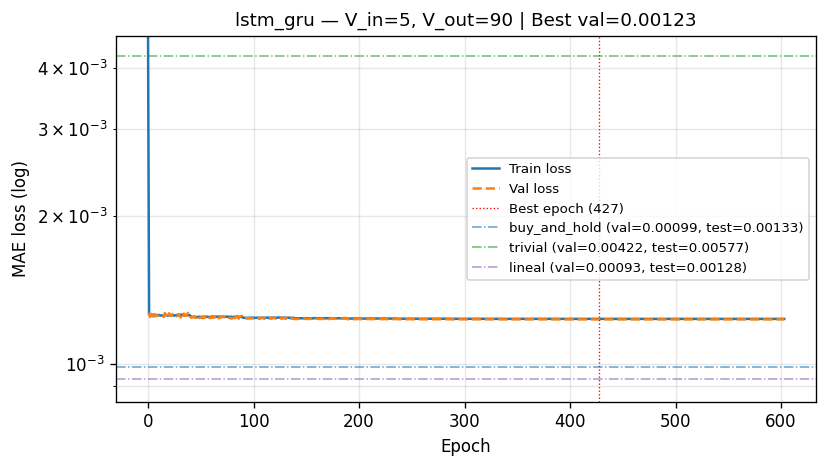

> Comparativa MAE — V_in=5, V_out=90


baseline,n_params,mae_train,mae_val,mae_test,mejora_test_%
lstm_gru,"120,727",0.00123,0.00123,0.00124,—
buy_and_hold,0,0.00134,0.00099,0.00133,+6.63%
trivial,0,0.00566,0.00422,0.00577,+78.55%
lineal,"2,668",0.00126,0.00093,0.00128,+3.06%



> MAE  train=0.0012  val=0.0012  test=0.0012  params=120,727
> Artefactos en: 08_results/runs/lstm_gru/lstm_gru_vin5_vout90/


In [7]:
maes = tracker.maes_last  # MAE train/val/test del best.keras de esta ejecución

plot_curva(history, MODELO, V_IN, V_OUT, mostrar_baselines=True, save=tracker.improved)
plt.show()

resumen_vs_baselines(maes, V_IN, V_OUT, nombre_modelo=MODELO, verbose=True, n_params=model.count_params())


print(f'\n> MAE  train={maes["train"]:.4f}  val={maes["val"]:.4f}  test={maes["test"]:.4f}'
      f'  params={model.count_params():,}')
print(f'> Artefactos en: 08_results/runs/{MODELO}/{MODELO}_vin{V_IN}_vout{V_OUT}/')